<h1 style="text-align: center;">Task-6P</h1>
<h3 style="text-align: right;">Name: Yatharth Deoly</h3>
<h3 style="text-align: right;">StudentId: 224207854</h3>
<h3 style="text-align: right;">EmailId: yatharthdeoly@gmail.com</h3>


## Introduction

In this task, we will be working with MNIST digits classification dataset that has been provided by Keras library. This is a dataset of 60,000 28x28 grayscale images of the 10 digits, along with a test set of 10,000 images.

Feature -> NumPy array of grayscale image data with shapes (, 28, 28), containing the data. Pixel values range from 0 to 255.
Target -> NumPy array of digit labels (integers in range 0-9)


Defining imports at the top that will be used by the report.
In this case, having all the imports at the top is more intuitive than having some of them at the top and some of them scattered over the file.

In [1]:
# Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python.
import matplotlib.pyplot as plt

# This command tells the IPython environment to draw the plots immediately after the current cell
%matplotlib inline

import warnings

# Ignore all warnings generated by the Python program
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

Load the MNIST Digit Dataset and Show the Size of the Training and Test Set

In [2]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Display the size of the training and test sets
print(f"Training set size: {x_train.shape[0]}")
print(f"Test set size: {x_test.shape[0]}")


Training set size: 60000
Test set size: 10000


Visualising sample data

Showing image from train dataset, with label as => 5


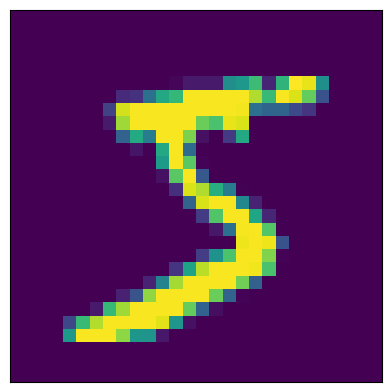

In [3]:
print(f"Showing image from train dataset, with label as => {y_train[0]}")

plt.matshow(x_train[0])
plt.xticks([])
plt.yticks([])

plt.show()

Showing image from test dataset, with label as => 7


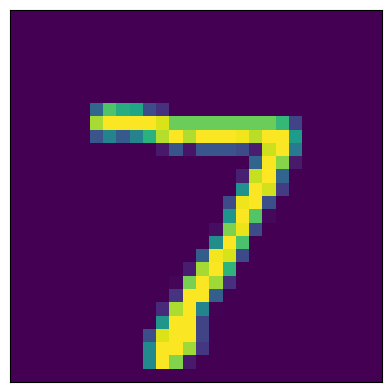

In [4]:
print(f"Showing image from test dataset, with label as => {y_test[0]}")

plt.matshow(x_test[0])
plt.xticks([])
plt.yticks([])

plt.show()

Pre-processign the dataset

In [5]:
num_classes = 10

# Preprocess the data
x_train = x_train.reshape(-1, 28*28).astype('float32') / 255
x_test = x_test.reshape(-1, 28*28).astype('float32') / 255

y_train = to_categorical(y_train,num_classes)
y_test = to_categorical(y_test,num_classes)

Developing an One Hidden Layer multi-layer perceptron model

In [6]:
# Build the model
model = Sequential([Flatten(input_shape=(28*28,))])
model.add(Dense(512, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8593 - loss: 0.5023 - val_accuracy: 0.9578 - val_loss: 0.1520
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9648 - loss: 0.1253 - val_accuracy: 0.9672 - val_loss: 0.1160
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9772 - loss: 0.0794 - val_accuracy: 0.9724 - val_loss: 0.0921
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9847 - loss: 0.0549 - val_accuracy: 0.9742 - val_loss: 0.0869
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9889 - loss: 0.0404 - val_accuracy: 0.9743 - val_loss: 0.0848
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9918 - loss: 0.0293 - val_accuracy: 0.9759 - val_loss: 0.0804
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9953 - loss: 0.0207 - val_accuracy: 0.9770 - val_loss: 0.0808
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9953 - loss: 0.0181 - val_accuracy: 

In [7]:
print(f"Test accuracy of 1 hidden layer MLP Model => {test_acc:.4f}")

Test accuracy of 1 hidden layer MLP Model => 0.9794


Set number of hidden layers for MLP model as [2,4,6,8,10] and checking accuracies

In [8]:
def create_model(num_hidden_layers):
  model = Sequential([Flatten(input_shape=(28*28,))])
  for _ in range(num_hidden_layers):
    model.add(Dense(100, activation='relu'))
  model.add(Dense(num_classes, activation='softmax'))
  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

In [9]:
hidden_layers = [2, 4, 6, 8, 10]
accuracies = []

for layers in hidden_layers:
    print(f"Model creation for {layers} hidden layers started..")
    model = create_model(layers)
    model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2, verbose=1)
    
    test_loss, test_acc = model.evaluate(x_test, y_test)
    accuracies.append(test_acc)
    print(f"Model creation for {layers} hidden layers ended..\n")

Model creation for 2 hidden layers started..
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8028 - loss: 0.7115 - val_accuracy: 0.9453 - val_loss: 0.1935
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9476 - loss: 0.1775 - val_accuracy: 0.9568 - val_loss: 0.1414
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9662 - loss: 0.1167 - val_accuracy: 0.9661 - val_loss: 0.1142
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9738 - loss: 0.0880 - val_accuracy: 0.9711 - val_loss: 0.1018
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9810 - loss: 0.0669 - val_accuracy: 0.9714 - val_loss: 0.0944
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9841 - loss: 0.0540 - val_accuracy: 0.9732 - val_loss: 0.0952
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9872 - loss: 0.0436 - val_accuracy: 0.9669 - val_loss: 0.1010
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accur

In [10]:
for num_layers, accuracy in zip(hidden_layers, accuracies):
  print(f"Number of hidden layers: {num_layers}, Test accuracy: {accuracy:.4f}")

Number of hidden layers: 2, Test accuracy: 0.9774
Number of hidden layers: 4, Test accuracy: 0.9757
Number of hidden layers: 6, Test accuracy: 0.9752
Number of hidden layers: 8, Test accuracy: 0.9763
Number of hidden layers: 10, Test accuracy: 0.9715


Impact of Number of Hidden Layers
- Increasing the number of hidden layers does not lead to a significant improvement in accuracy. In fact, there's a slight tendency for accuracy to decrease as the number of layers increases beyond 2.
- A larger number of layers could potentially lead to overfitting, where the model becomes too complex and starts memorizing the training data rather than learning generalizable patterns.

Set hidden layer size for MLP model as [50, 100, 150, 200] and checking Accuracies

In [11]:
def create_model(hidden_layer_size):
  model = Sequential([Flatten(input_shape=(28*28,))])
  model.add(Dense(hidden_layer_size, activation='relu'))
  model.add(Dense(num_classes, activation='softmax'))
  
  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

  return model

In [12]:
hidden_sizes = [50, 100, 150, 200]
accuracies = []

for size in hidden_sizes:
    print(f"Model creation for {size} hidden layer size started..")
    model = create_model(size)
    model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2, verbose=1)
    
    test_loss, test_acc = model.evaluate(x_test, y_test)
    accuracies.append(test_acc)
    print(f"Model creation for {size} hidden layer size ended..\n")


Model creation for 50 hidden layer size started..


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7670 - loss: 0.8624 - val_accuracy: 0.9283 - val_loss: 0.2594
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9288 - loss: 0.2500 - val_accuracy: 0.9420 - val_loss: 0.2096
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9437 - loss: 0.2022 - val_accuracy: 0.9511 - val_loss: 0.1748
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9541 - loss: 0.1625 - val_accuracy: 0.9570 - val_loss: 0.1567
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9614 - loss: 0.1363 - val_accuracy: 0.9606 - val_loss: 0.1424
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9656 - loss: 0.1221 - val_accuracy: 0.9626 - val_loss: 0.1355
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9688 - loss: 0.1091 - val_accuracy: 0.9652 - val_loss: 0.1279
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9723 - loss: 0.0984 - val_accuracy: 0.

In [13]:
for size, accuracy in zip(hidden_sizes, accuracies):
  print(f"Hidden layer size: {size}, Test accuracy: {test_acc:.4f}")

Hidden layer size: 50, Test accuracy: 0.9778
Hidden layer size: 100, Test accuracy: 0.9778
Hidden layer size: 150, Test accuracy: 0.9778
Hidden layer size: 200, Test accuracy: 0.9778


Impact of Hidden Layer Size
- The model's accuracy remains remarkably consistent across different hidden layer sizes. This suggests that for the MNIST dataset, a relatively small hidden layer size is sufficient to capture the underlying patterns.
- Given the consistent performance, using a smaller hidden layer size (like 50) can be advantageous in terms of computational efficiency and model complexity without sacrificing accuracy.

Conclusion:
- A simple MLP model with a single hidden layer and a moderate size of 50 neurons performs good.
- Increasing the complexity of the model (more layers or larger layers) does not necessarily lead to better performance and can potentially introduce overfitting.

What more can be done:
- Techniques like dropout or L1/L2 regularizatio or early stopping could be explored to mitigate overfitting if it becomes a significant issue.
- Hyperparameter tunining can be perfomed for activation functions(like LeakyReLU, Tanh and more), learning rate, batch size and more.
- Can use more better models like CNN and can search for pre-exisitng models.

# Summary

In this report we have learnt about MNIST dataset from Keras, where we build a multi-layer perceptron model with different requirements of hidden layers and hidden layer sizes. Here we have learnt about different libraries from python, sklearn , tensorflow from loading the dataset to the modelling and then checking metrics of different models.

# References

- https://keras.io/api/datasets/mnist/
- Different blogs from https://medium.com/ like
  - https://medium.com/analytics-vidhya/deep-learning-tutorial-with-keras-7a34a1a322cd
  - https://medium.com/@BrendanArtley/mnist-keras-simple-cnn-99-6-731b624aee7f
- https://keras.io/api/models/sequential/#sequential-class
- https://keras.io/api/models/model_training_apis/
- https://keras.io/api/optimizers/adam/
- https://keras.io/api/metrics/accuracy_metrics/
